# 0. Setting

In [ ]:
import os
os.chdir("./masf") # change to the root directory of the project

import jax
import torch 
import seaborn as sns
from utils.visualizations import plot_vorticity_row

seed = 0 
device = 'cuda'
jax.config.update("jax_platforms", "cpu") 

# 1. Prior generation 

In [ ]:
from dynamics import KolmogorovFlow

steps = [50] # 50th step state as the prior for the measurement model.
batch_size = 5
dynamics = KolmogorovFlow(grid_size=128,reynolds=1000,dt=0.2,seed=seed)

x0 = dynamics.prior(batch_size).to(device) #[5, 2, 128,128] True
x50 = dynamics.states_at(x0, steps) #[1, 5, 2, 128, 128]
prior50  = x50[0].to(device) #[5, 2, 128, 128]  at 50

# 2. Linear measurement equation

## 2.1. Grid Mask

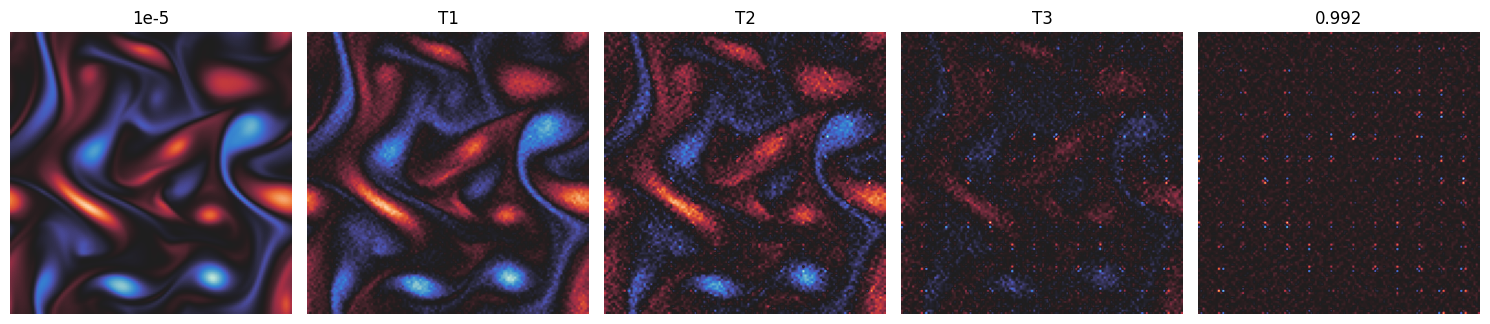

In [ ]:
from measurements import GridMask

measurement = GridMask(noise_std=0.1, 
                       stride=10, 
                       grid_size=128,
                       device = device)
measurement.update_stats(prior50)

norm_prior50 = measurement.norm.norm(prior50[0].repeat(5, 1, 1, 1))
t = torch.linspace(1e-5, 0.992, batch_size).to(device) 
x_t, _ = measurement.forward_process(norm_prior50,t) #[5, 2, 128, 128]

plot_vorticity_row(x_t.squeeze(0), cmap=sns.cm.icefire, titles=["1e-5", "T1", "T2", "T3", "0.992"])


## 2.2. Center Mask

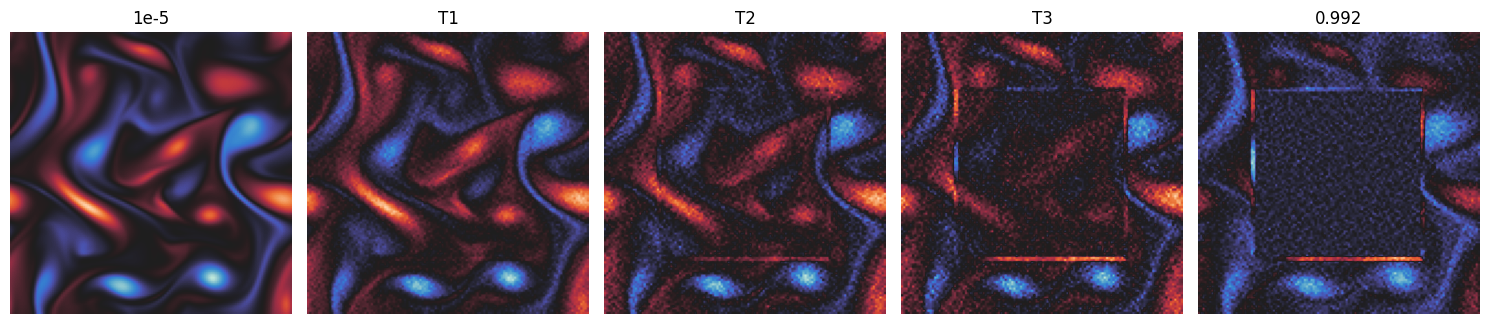

In [ ]:
from measurements import CenterMask

measurement = CenterMask(noise_std=0.1, 
                         hole_ratio=0.6, 
                         grid_size=128, 
                         device = device)
measurement.update_stats(prior50)

norm_prior50 = measurement.norm.norm(prior50[0].repeat(5, 1, 1, 1))
t = torch.linspace(1e-5, 0.992, batch_size).to(device) 
x_t, _ = measurement.forward_process(norm_prior50,t) #[5, 2, 128, 128]

plot_vorticity_row(x_t.squeeze(0), cmap=sns.cm.icefire, titles=["1e-5", "T1", "T2", "T3", "0.992"])


# 3. Nonlinear measurement equation

## 3.1. Sigmoid

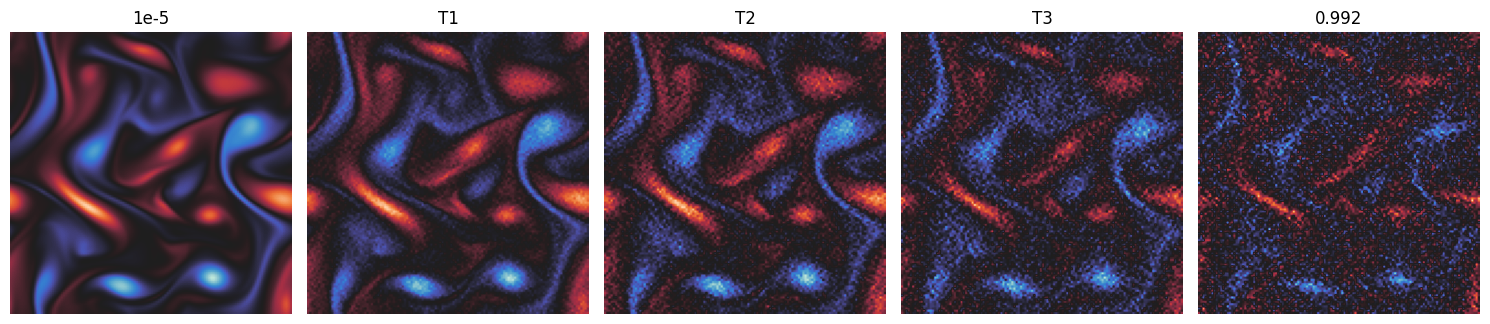

In [ ]:
from measurements import Nonlinear

measurement = Nonlinear(noise_std=0.1, 
                        type="sigmoid", # sigmoid | tanh | speed
                        alpha=2,
                        device = device)
measurement.update_stats(prior50)

norm_prior50 = measurement.norm.norm(prior50[0].repeat(5, 1, 1, 1))
t = torch.linspace(0.0, 0.992, batch_size).to(device) 
x_t, _ = measurement.forward_process(norm_prior50,t) #[5, 2, 128, 128]

plot_vorticity_row(x_t.squeeze(0), cmap=sns.cm.icefire, titles=["1e-5", "T1", "T2", "T3", "0.992"])


## 3.2. Speed

x_t tensor(-1.7172, device='cuda:0') tensor(2.3449, device='cuda:0')


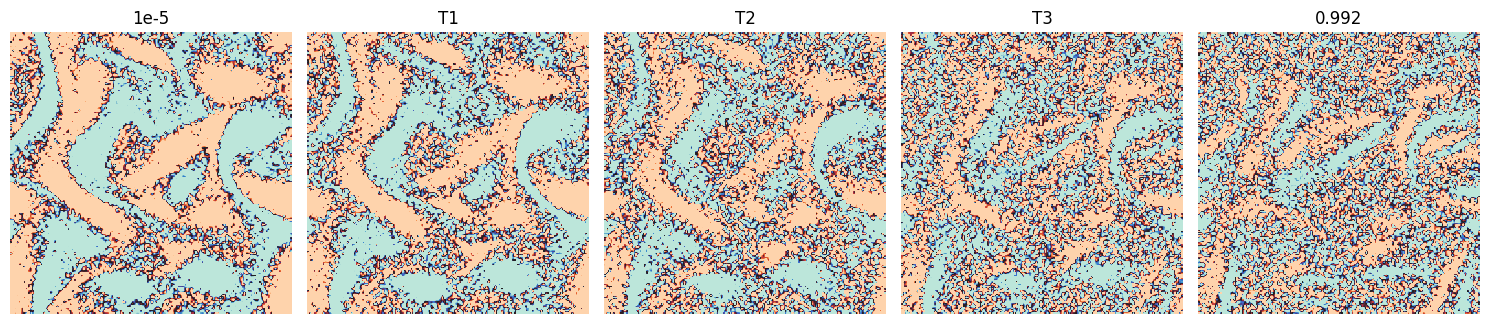

In [ ]:
from measurements import Nonlinear

measurement = Nonlinear(noise_std=0.1, 
                        type="speed", # sigmoid | tanh | speed
                        device = device)
measurement.update_stats(prior50)

norm_prior50 = measurement.norm.norm(prior50[0].repeat(5, 1, 1, 1))
t = torch.linspace(0.5, 0.992, batch_size).to(device) 
x_t, _ = measurement.forward_process(norm_prior50,t) #[5, 2, 128, 128]
print('x_t', x_t.min(), x_t.max())
plot_vorticity_row(x_t.squeeze(0), cmap=sns.cm.icefire, titles=["1e-5", "T1", "T2", "T3", "0.992"])
